# **PCLab#6** - Group 10 - Clement Guyot de la Pommeraye, Erik van der Sangen, Jacopo Cagnacci, Giacomo Bellodi

* **Time spent**: 3.5hrs x team member
* **Level of difficulty**: 8/10

### **Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **Task 1** : Basic manipulation and descriptive statistics

In [4]:
data = pd.read_csv('Data_PCLab5_train_test.csv')
data.head(5)

,industry,credit_score,year,turnover,year_creation,total_actif,id,total_asset,net_total_asset,margin,...,stable_debt,financial_debt,tot_debt,investment,ppe,intangible,ppent,sales,capital,nbemp
0,47,3,2016,1.793,2006.0,1951,1479243776825,2120.0,1951.0,0.588608,...,335.0,336.0,560.0,7.0,217.0,0.0,380.0,1793.0,1588.0,4.0
1,68,6,2012,0.037,2003.0,365,1353691776396,530.0,365.0,0.000000,...,0.0,592.0,603.0,0.0,508.0,0.0,673.0,37.0,508.0,0.0
2,47,5+,2016,1.899,2004.0,1730,1359587200964,1805.0,1730.0,0.000000,...,180.0,206.0,423.0,0.0,76.0,0.0,151.0,1899.0,1373.0,0.0
3,55,4,2004,1.085,2000.0,1945,1296533120972,2559.0,1945.0,0.000000,...,888.0,1235.0,1499.0,13.0,1587.0,0.0,2061.0,1085.0,2018.0,3.0
4,59,5+,2012,1.350,1996.0,2372,1229382656899,3020.0,2372.0,0.250000,...,57.0,320.0,915.0,26.0,113.0,0.0,197.0,1350.0,2093.0,8.0


### **Describe the sample**

In [5]:
#variables in the dataset
data.columns

Index(['industry', 'credit_score', 'year', 'turnover', 'year_creation',
       'total_actif', 'id', 'total_asset', 'net_total_asset', 'margin', 'wcr',
       'sfc', 'bank_debt', 'bank_debt_lt', 'other_debt', 'tot_debt1',
       'tot_debt2', 'equity1', 'equity2', 'stable_debt', 'financial_debt',
       'tot_debt', 'investment', 'ppe', 'intangible', 'ppent', 'sales',
       'capital', 'nbemp'],
      dtype='object')

**What are the different credit scores in the data ? What does it mean ?**

In [6]:
data['credit_score'].unique()

array(['3', '6', '5+', '4', '4+', '3+', '5', '7', '3++', 'P', '8', '9'],
      dtype=object)

The scores range from 3++ to P, where 3++ is the highest credit score (positive) and P is the lowest (negative).
The scale is as follows:

3++, 3+, 3, 4+, 4, 5+, 5, 6, 7, 8, 9, P.

In [7]:
num_cols = data.select_dtypes(include=[np.number]).columns

# Base description with extended percentiles
desc = data[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

#distribution diagnostics
desc["skew"] = data[num_cols].skew(numeric_only=True)
desc["kurtosis"] = data[num_cols].kurtosis(numeric_only=True)
desc["iqr"] = desc["75%"] - desc["25%"]
desc["missing_pct"] = data[num_cols].isna().mean() * 100
desc["zero_pct"] = (data[num_cols] == 0).mean() * 100
desc["unique"] = data[num_cols].nunique(dropna=False)

# Rough outlier rate using IQR (outlier if smaller that Q1 - 1.5 * IQR or grater than Q3 + 1.5 * IQR)
Q1 = desc["25%"]
Q3 = desc["75%"]
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_rate = {}
for c in num_cols:
    s = data[c].dropna()
    if s.shape[0] == 0:
        outlier_rate[c] = np.nan
        continue
    lo = lower.loc[c]
    hi = upper.loc[c]
    outlier_rate[c] = 100 * ((s < lo) | (s > hi)).mean()
desc["outlier_pct"] = pd.Series(outlier_rate)

#formatting
desc = desc.rename(columns={
    "mean":"mean",
    "std":"std",
    "min":"min",
    "max":"max",
    "50%":"median"
}).sort_index()

# full table
display(desc.round(3))

# Quick spotlight views
print("\nTop 10 most right/left-skewed:")
display(desc.reindex(desc["skew"].abs().sort_values(ascending=False).index).head(10)[["skew","kurtosis","missing_pct","zero_pct","outlier_pct"]].round(3))

print("\nTop 10 highest missing percentage:")
display(desc.sort_values("missing_pct", ascending=False).head(10)[["missing_pct","zero_pct","skew","kurtosis"]].round(3))

print("\nTop 10 highest zero percentage:")
display(desc.sort_values("zero_pct", ascending=False).head(10)[["zero_pct","missing_pct","skew","kurtosis"]].round(3))

print("\nTop 10 highest outlier percentage:")
display(desc.sort_values("outlier_pct", ascending=False).head(10)[["outlier_pct","skew","kurtosis","missing_pct","zero_pct"]].round(3))


,count,mean,std,min,1%,5%,25%,median,75%,95%,99%,max,skew,kurtosis,iqr,missing_pct,zero_pct,unique,outlier_pct
bank_debt,18903.0,1.371051e+03,2.911777e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.900000e+01,2.920000e+02,2.029900e+03,1.403456e+04,3.363693e+06,87.580,9577.827,2.920000e+02,0.000,28.440,2397,12.882
bank_debt_lt,18903.0,1.263527e+03,2.867733e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,2.010000e+02,1.650900e+03,1.254674e+04,3.309052e+06,87.354,9536.054,2.010000e+02,0.000,39.073,2135,14.278
capital,18902.0,1.318348e+04,3.912999e+05,0.000000e+00,0.000000e+00,1.700000e+01,1.852500e+02,5.575000e+02,1.667750e+03,1.534295e+04,1.146162e+05,3.495901e+07,76.520,6517.120,1.482500e+03,0.005,2.037,5302,13.030
equity1,18903.0,4.300502e+03,7.685775e+04,-1.680830e+05,-2.612900e+03,-3.769000e+02,8.500000e+01,3.420000e+02,9.970000e+02,8.065600e+03,5.650394e+04,5.932367e+06,54.571,3558.115,9.120000e+02,0.000,0.180,5282,14.680
equity2,18903.0,5.605650e+02,6.546472e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.898000e+01,8.962726e+06,135.827,18586.493,0.000000e+00,0.000,98.752,176,1.248
financial_debt,18902.0,3.125931e+03,5.674088e+04,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,1.670000e+02,6.330000e+02,4.622750e+03,3.624049e+04,4.745506e+06,57.680,3998.701,6.010000e+02,0.005,10.379,3391,12.475
id,18903.0,1.352825e+12,3.879205e+11,1.245183e+10,2.384131e+11,9.427460e+11,1.147480e+12,1.296614e+12,1.482993e+12,2.331180e+12,2.658542e+12,2.996679e+12,1.230,3.507,3.355130e+11,0.000,0.000,18903,9.184
industry,18903.0,5.058800e+01,1.807400e+01,0.000000e+00,1.000000e+00,1.600000e+01,4.300000e+01,4.700000e+01,6.400000e+01,8.100000e+01,9.300000e+01,9.600000e+01,-0.212,0.338,2.100000e+01,0.000,0.005,83,4.401
intangible,18902.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000,0.000,0.000000e+00,0.005,99.995,2,0.000
investment,18902.0,5.995680e+02,1.721670e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00,4.400000e+01,5.360000e+02,4.464920e+03,1.523866e+06,67.824,5276.015,4.400000e+01,0.005,32.952,1316,14.877



Top 10 most right/left-skewed:


,skew,kurtosis,missing_pct,zero_pct,outlier_pct
equity2,135.827,18586.493,0.000,98.752,1.248
other_debt,93.418,9733.153,0.000,98.847,1.153
ppe,92.890,10082.227,0.005,8.649,13.443
wcr,-91.079,9861.818,0.000,16.913,18.791
ppent,89.211,9303.144,0.005,8.655,13.210
bank_debt,87.580,9577.827,0.000,28.440,12.882
bank_debt_lt,87.354,9536.054,0.000,39.073,14.278
capital,76.520,6517.120,0.005,2.037,13.030
stable_debt,74.997,7227.347,0.000,28.223,12.945
nbemp,74.321,6234.798,0.005,15.299,10.359



Top 10 highest missing percentage:


,missing_pct,zero_pct,skew,kurtosis
year_creation,0.360,0.000,-2.491,11.507
capital,0.005,2.037,76.520,6517.120
nbemp,0.005,15.299,74.321,6234.798
investment,0.005,32.952,67.824,5276.015
intangible,0.005,99.995,0.000,0.000
tot_debt,0.005,0.063,43.498,2208.242
ppent,0.005,8.655,89.211,9303.144
sales,0.005,3.640,67.183,5377.881
ppe,0.005,8.649,92.890,10082.227
financial_debt,0.005,10.379,57.680,3998.701



Top 10 highest zero percentage:


,zero_pct,missing_pct,skew,kurtosis
intangible,99.995,0.005,0.000,0.000
other_debt,98.847,0.000,93.418,9733.153
equity2,98.752,0.000,135.827,18586.493
bank_debt_lt,39.073,0.000,87.354,9536.054
investment,32.952,0.005,67.824,5276.015
bank_debt,28.440,0.000,87.580,9577.827
stable_debt,28.223,0.000,74.997,7227.347
margin,21.288,0.000,-45.240,3483.690
wcr,16.913,0.000,-91.079,9861.818
sfc,16.500,0.000,64.486,4486.623



Top 10 highest outlier percentage:


,outlier_pct,skew,kurtosis,missing_pct,zero_pct
wcr,18.791,-91.079,9861.818,0.000,16.913
sfc,15.336,64.486,4486.623,0.000,16.500
investment,14.877,67.824,5276.015,0.005,32.952
equity1,14.680,54.571,3558.115,0.000,0.180
bank_debt_lt,14.278,87.354,9536.054,0.000,39.073
total_asset,13.501,69.286,5509.352,0.000,0.048
ppe,13.443,92.890,10082.227,0.005,8.649
net_total_asset,13.405,68.321,5937.442,0.000,0.074
total_actif,13.374,68.319,5937.241,0.000,0.074
ppent,13.210,89.211,9303.144,0.005,8.655


**Are there any useless variables ?**

We indentified two usless variables:
- **id**: it is a unique identifier assigned to each firm. It does not contain any economic or financial information and therefore has no predictive power for the firm’s credit score.
- **intangible**: this column has only one unique value across all observations, meaning it does not vary between firms. Therefore does not provide information to the ML models.

- Additionally, the variables **other_debt** and **equity2** can be considered useless as for 99% of the cases they present the same value.


 **Which are the key findings relative to the variables’ distributions ?**


- **Heavy right-skew and fat tails.** Most size/level variables (e.g., total_asset, net_total_asset, total_actif, ppe, ppent, sales, debt variables) are extremely right-skewed with very high kurtosis (e.g., equity2 skew ≈ 219, kurtosis ≈ 48k). This reflects large firm-size heterogeneity and many extreme upper-tail values.
- **Zero sparsity in several features.** As sais above, intangible is always zero (100% zeros → useless). Very high zero shares for other_debt (98.9%), equity2 (98.7%), and sizeable zeros for bank_debt_lt (39%), investment (32%), bank_debt (28%), stable_debt (28%), margin (20.8%), wcr (16.6%), sfc (16.2%). These columns have mass at zero plus long right tails.
- **Many statistical outliers**.
Highest outlier rates: wcr (18.8%), sfc (15.6%), investment (15.1%), equity1 (14.4%), bank_debt_lt (14.3%), then large size variables (total_asset, ppe, net_total_asset, ppent, total_actif) ~13%. This supports using clipping/winsorization or robust transforms.

### **Plot the distribution of the variables against the different credit scores**

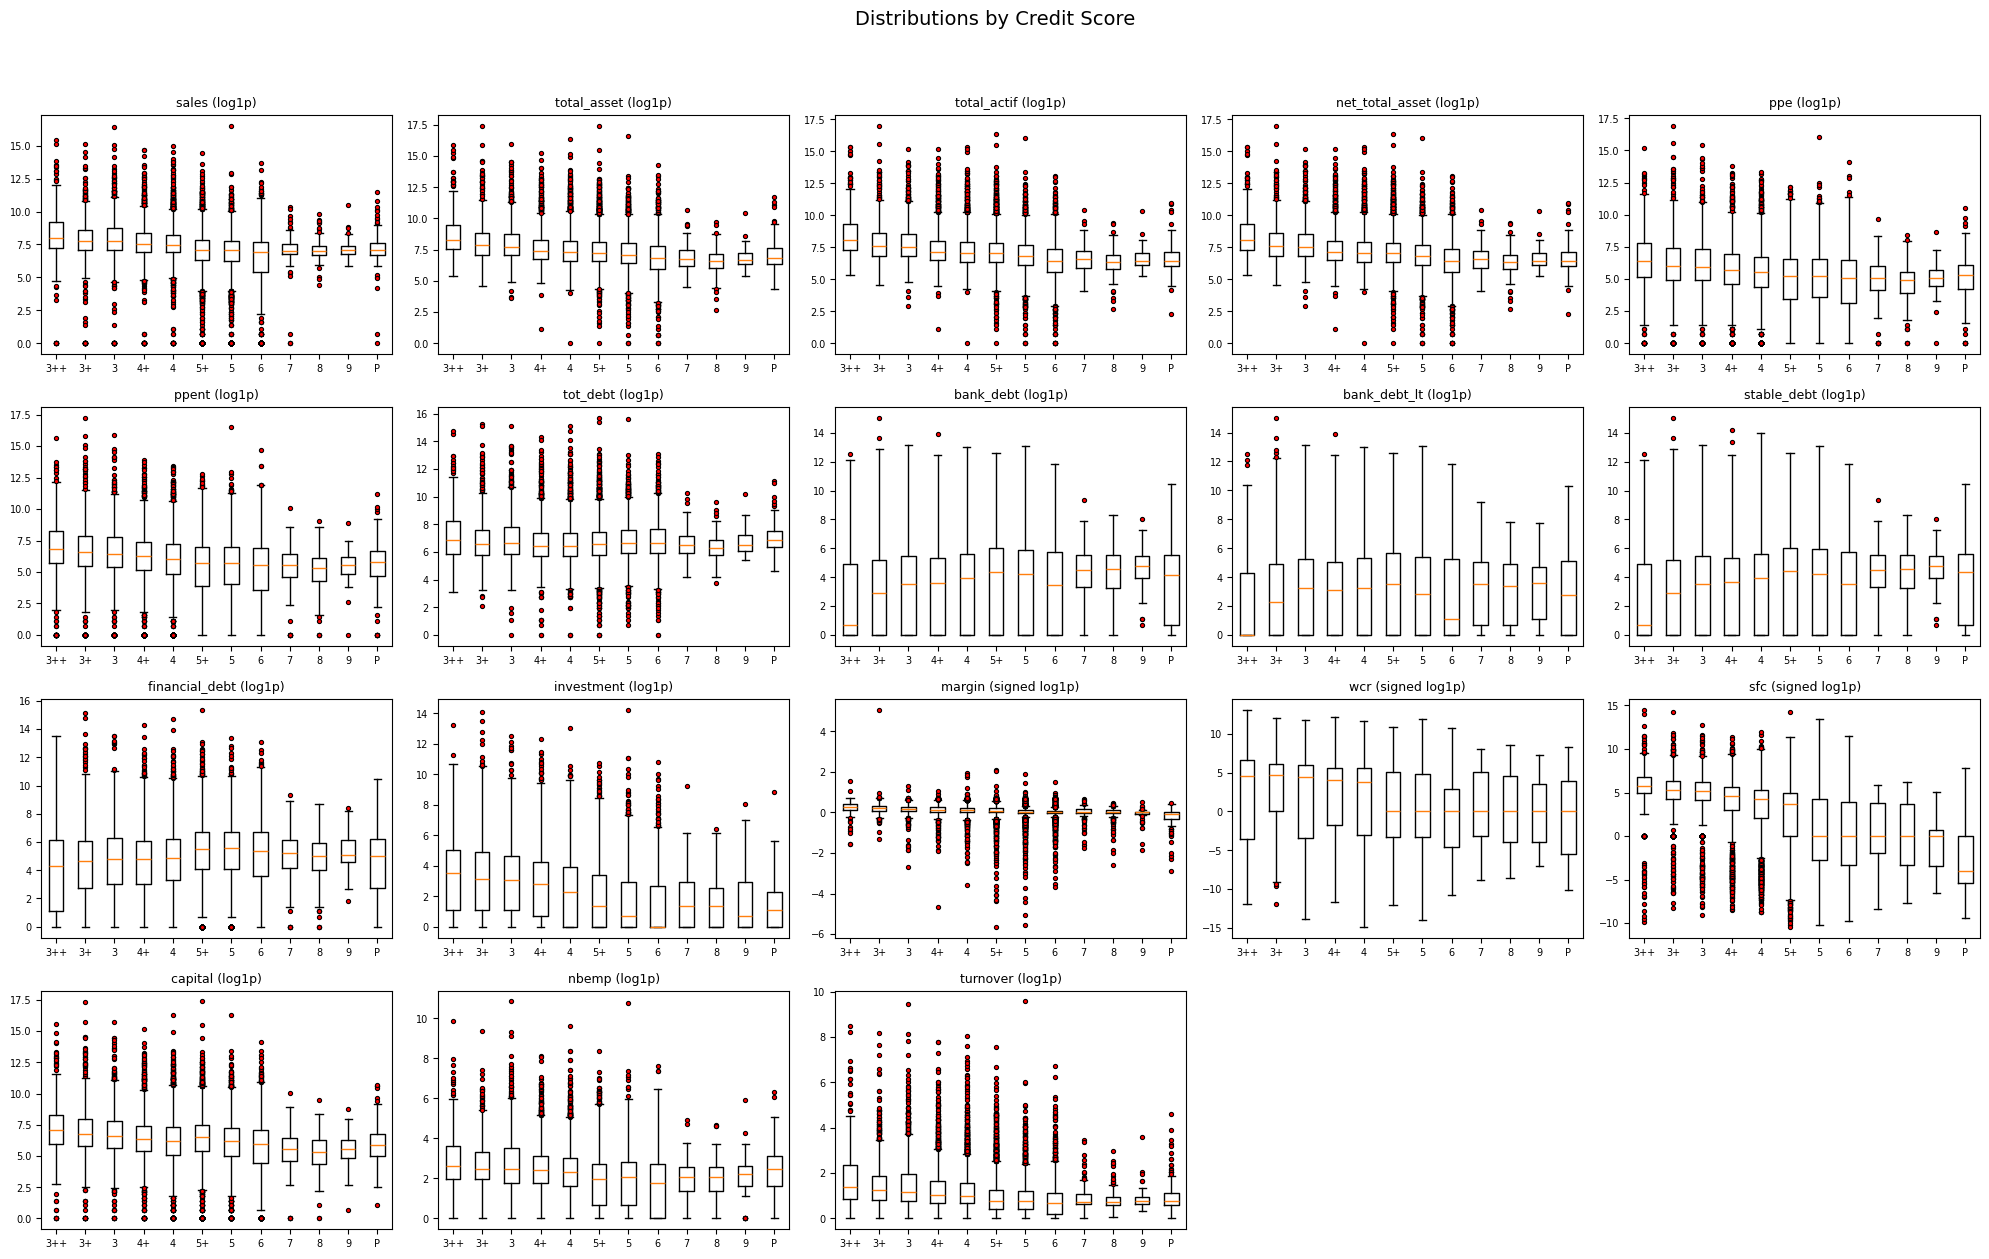

In [8]:
###  Boxplots by credit_score with outliers

import matplotlib.pyplot as plt
import math

# 1) credit score order
score_order = ["3++", "3+", "3", "4+", "4", "5+", "5", "6", "7", "8", "9", "P"]
cs = data["credit_score"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
data = data.copy()
data["credit_score_ord"] = pd.Categorical(cs, categories=score_order, ordered=True)

# 2) Variables to plot (we picked some of the most meaningful to our descretion)
preferred = [
    "sales", "total_asset", "total_actif", "net_total_asset",
    "ppe", "ppent", "tot_debt", "bank_debt", "bank_debt_lt",
    "stable_debt", "financial_debt", "investment",
    "margin", "wcr", "sfc", "capital", "nbemp", "turnover"
]
vars_to_plot = [c for c in preferred if c in data.columns]
if not vars_to_plot:
    exclude_cols = [c for c in data.columns if "id" in c.lower()] + ["year", "credit_score", "credit_score_ord"]
    vars_to_plot = [c for c in data.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

# 3) Transform logic (choose once per variable so groups are comparable)
def transform_for_plot(series: pd.Series):
    s = series.dropna().astype(float)
    if s.nunique() < 3:
        return s, "low-var"
    if (s.min() >= 0) and (s.max() > 0) and (abs(s.skew()) > 1):
        return np.log1p(s), "log1p"              # non-negative, skewed
    if (s.min() < 0) and (s.max() > 0) and (abs(s.skew()) > 1):
        return np.sign(s) * np.log1p(np.abs(s)), "signed log1p"  # mixed-sign, skewed
    return s, "linear"

# 4) Plot with visible outliers
n = len(vars_to_plot)
ncols = 5
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3.2 * nrows))
axes = np.ravel(axes) if n > 1 else [axes]

# Style for outliers
flierprops = dict(marker='o', markersize=3, markerfacecolor='red', markeredgewidth=0.8)

for i, col in enumerate(vars_to_plot):
    ax = axes[i]
    # Transform once on the whole column
    transformed, tlabel = transform_for_plot(data[col])
    tmp = pd.Series(transformed, index=data.index, name=col)

    # Build grouped data
    grouped, labels = [], []
    for s in score_order:
        vals = tmp[data["credit_score_ord"] == s].dropna().values
        if len(vals) == 0:
            continue
        grouped.append(vals)
        labels.append(s)

    if len(grouped) < 2:
        ax.axis("off")
        continue

    ax.boxplot(
        grouped,
        tick_labels=labels,
        showfliers=True,
        whis=1.5,               # (1.5 IQR)
        flierprops=flierprops
    )
    ax.set_title(f"{col} ({tlabel})", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Hide any leftover axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Distributions by Credit Score", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


The largest number of outliers appear in size-related and debt-related variables — especially **sales, total_asset, net_total_asset, ppe, ppent, tot_debt, and financial_debt**. These variables have long upper tails, consistent with large firms dominating the upper end of the sample.

### **Deal with the outliers within the sample, if any.**

In [9]:
# variables ranked by % of outliers defined before. Remark: a value is outlier if small than Q1 - IQR*1.5 or grater than 1.5*IQR + Q3.
desc['outlier_pct'].sort_values(ascending = False)

,outlier_pct
wcr,18.790668
sfc,15.336190
investment,14.876733
equity1,14.680209
bank_debt_lt,14.278157
total_asset,13.500503
ppe,13.443022
net_total_asset,13.405280
total_actif,13.373539
ppent,13.210242


The data contains a lot of outliers. This is normal for financial data, as companies are of different sizes and can present widely different numbers. Therefore, we winsorize numeric variables only at the 1st and 99th percentiles.

In [10]:
data_capped = data.copy()

# Exclude identifiers and non-feature columns
exclude_cols = [c for c in data_capped.columns if any(tok in c.lower() for tok in ['id'])] + ['year', 'credit_score', 'credit_score_ord']
num_cols = [c for c in data_capped.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

#Winsorize at [1%, 99%]
for col in num_cols:
    q01, q99 = data_capped[col].quantile([0.01, 0.99])
    data_capped[col] = data_capped[col].clip(lower=q01, upper=q99)

In [11]:
# Create 'company_age' using 'year' and 'year_creation'
data_capped['company_age'] = data_capped['year'] - data_capped['year_creation']

# Display the first few rows with the new column
display(data_capped[['year', 'year_creation', 'company_age']].head())

,year,year_creation,company_age
0,2016,2006.0,10.0
1,2012,2003.0,9.0
2,2016,2004.0,12.0
3,2004,2000.0,4.0
4,2012,1996.0,16.0


## **Task 2** : Feature selection

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder
import warnings
num_cols = num_cols + ['company_age']  # Include the new feature

# Suppress warnings for clarity
warnings.filterwarnings("ignore", category=UserWarning)

# We need to convert the categorical credit_score to numerical for feature selection
# using f_classif which is for classification tasks.
# We will use the capped data since it has fewer extreme values.
data_for_selection = data_capped.copy()

# Drop rows with missing values in credit_score or the numerical features
data_for_selection.dropna(subset=['credit_score'] + num_cols, inplace=True)

# Convert credit_score to numerical labels
label_encoder = LabelEncoder()
data_for_selection['credit_score_encoded'] = label_encoder.fit_transform(data_for_selection['credit_score'])

# Define features (X) and target (y)
X = data_for_selection[num_cols]
y = data_for_selection['credit_score_encoded']

# Select the top K features based on the ANOVA F-value
# Let's start by selecting the top 10 features, you can adjust K as needed
k = 10
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)

# Get the selected feature names
selected_features_mask = selector.get_support()
selected_features = X.columns[selected_features_mask]

print(f"Selected top {k} features based on f_classif score:")
print(selected_features.tolist())

# You can also get the scores for all features
feature_scores = pd.DataFrame({'feature': X.columns, 'score': selector.scores_})
display(feature_scores.sort_values(by='score', ascending=False))

Selected top 10 features based on f_classif score:
['turnover', 'year_creation', 'net_total_asset', 'margin', 'sfc', 'equity1', 'investment', 'sales', 'nbemp', 'company_age']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,feature,score
6,margin,110.805110
8,sfc,105.564140
26,company_age,80.684465
14,equity1,66.007878
2,year_creation,57.134283
1,turnover,42.667054
23,sales,42.666861
25,nbemp,34.929370
19,investment,30.831807
5,net_total_asset,27.636246


## **Optional Task 2** : Feature importance

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare data for the model (using data_capped and numerical features)
# Drop rows with missing values in credit_score or the numerical features
data_for_model = data_capped.copy().dropna(subset=['credit_score'] + num_cols)

# Convert credit_score to numerical labels
label_encoder = LabelEncoder()
data_for_model['credit_score_encoded'] = label_encoder.fit_transform(data_for_model['credit_score'])

X_model = data_for_model[num_cols]
y_model = data_for_model['credit_score_encoded']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

# Train a Random Forest Classifier model
model = RandomForestClassifier(n_estimators=100, random_state=42) # Using random_state for reproducibility
model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.DataFrame({'feature': X_model.columns, 'importance': model.feature_importances_})

# Display feature importances
display(feature_importances.sort_values(by='importance', ascending=False))

,feature,importance
14,equity1,0.088242
8,sfc,0.051678
23,sales,0.046578
6,margin,0.045267
1,turnover,0.044766
13,tot_debt2,0.043440
7,wcr,0.043108
24,capital,0.043003
17,financial_debt,0.042188
4,total_asset,0.040473


Spearman rank correlation between f_classif and RF ranks: 0.659
Selected by SelectKBest (k=10): ['turnover', 'year_creation', 'net_total_asset', 'margin', 'sfc', 'equity1', 'investment', 'sales', 'nbemp', 'company_age']
Top 10 by RandomForest importance: ['equity1', 'sfc', 'sales', 'margin', 'turnover', 'tot_debt2', 'wcr', 'capital', 'financial_debt', 'total_asset']
Overlap (5 features): ['equity1', 'margin', 'sales', 'sfc', 'turnover']


<Figure size 1000x900 with 0 Axes>

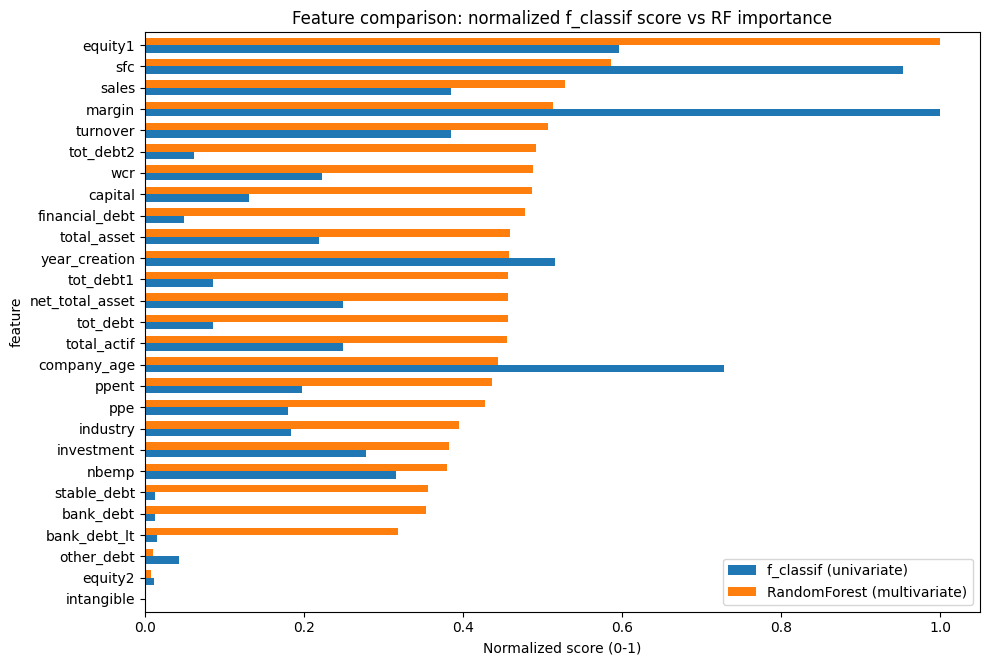

In [14]:
# compare SelectKBest (f_classif) scores vs RandomForest importances

# prepare comparison table
fs = feature_scores.set_index('feature')['score'].fillna(0)
rf = feature_importances.set_index('feature')['importance'].fillna(0)
cmp = pd.DataFrame({'f_score': fs, 'rf_imp': rf})
cmp['f_rank'] = cmp['f_score'].rank(ascending=False, method='min')
cmp['rf_rank'] = cmp['rf_imp'].rank(ascending=False, method='min')
cmp = cmp.sort_values('rf_rank')

# spearman rank correlation
spearman_rank_corr = cmp['f_rank'].corr(cmp['rf_rank'], method='spearman')

# top lists and overlap
k_sel = len(selected_features)
top_k_rf = list(cmp.sort_values('rf_imp', ascending=False).head(k_sel).index)
overlap = set(selected_features).intersection(top_k_rf)

print(f"Spearman rank correlation between f_classif and RF ranks: {spearman_rank_corr:.3f}")
print(f"Selected by SelectKBest (k={k_sel}): {selected_features.tolist()}")
print(f"Top {k_sel} by RandomForest importance: {top_k_rf}")
print(f"Overlap ({len(overlap)} features): {sorted(overlap)}")

# simple visualization
plt.figure(figsize=(10, max(4, len(cmp)/3)))
cmp_norm = cmp[['f_score', 'rf_imp']].copy()
# normalize for plotting on same scale
cmp_norm = (cmp_norm - cmp_norm.min()) / (cmp_norm.max() - cmp_norm.min())
cmp_norm.sort_values('rf_imp', inplace=True)
cmp_norm.plot(kind='barh', stacked=False, width=0.7, figsize=(10, max(4, len(cmp)/4)))
plt.xlabel('Normalized score (0-1)')
plt.title('Feature comparison: normalized f_classif score vs RF importance')
plt.legend(['f_classif (univariate)', 'RandomForest (multivariate)'])
plt.tight_layout()
plt.show()

## **Task 3** : Predict credit scores

In [15]:
# === CREDIT SCORE MODEL (fine-grained classes) — RF + Logistic Regression (FAST) ===
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, accuracy_score, classification_report
import numpy as np
import pandas as pd


# 1) Define pipelines

rf_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sel", SelectKBest(score_func=f_classif, k=10)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42))
])

# Logistic Regression: scale -> select 10 -> multinomial LR
# Use 'saga' (handles multinomial + class_weight), L2 penalty
lr_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("sel", SelectKBest(score_func=f_classif, k=10)),
    ("lr", LogisticRegression(
        multi_class="multinomial",
        solver="saga",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42))
])


# 2) Soft voting ensemble

voting = VotingClassifier(
    estimators=[("rf", rf_pipe), ("lr", lr_pipe)],
    voting="soft",   # needs predict_proba (OK for RF & LR)
    n_jobs=-1
)


# 3) Fit & evaluate

voting.fit(X_train, y_train)
y_test_pred = voting.predict(X_test)

recall_macro = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
acc = accuracy_score(y_test, y_test_pred)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"Macro Recall (TP ratio): {recall_macro:.4f}")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

# Per-class recall (TP ratio per original label)
rec_per_class = recall_score(y_test, y_test_pred, average=None, zero_division=0)
for cls, rec in zip(label_encoder.classes_, rec_per_class):
    print(f"Recall for {cls}: {rec:.4f}")


# 4) Predict on predict dataset

pred_df = pd.read_csv('Data_PCLab5_pred.csv')

# Create company_age if missing
if 'company_age' not in pred_df.columns:
    if {'year', 'year_creation'}.issubset(pred_df.columns):
        pred_df['company_age'] = pred_df['year'] - pred_df['year_creation']
    else:
        pred_df['company_age'] = np.nan

# Ensure all numeric features exist (use the union used in training)
for c in num_cols:
    if c not in pred_df.columns:
        pred_df[c] = 0.0

# Determine the exact feature names the fitted pipelines expect.
# The SimpleImputer stored feature_names_in_ when fitted; use that to align columns.
feat_names = None
try:
    # try to get from the 'rf' estimator in the voting classifier
    feat_names = list(voting.named_estimators_['rf'].named_steps['imp'].feature_names_in_)
except Exception:
    try:
        # fallback: use first estimator pipeline
        feat_names = list(voting.estimators_[0][1].named_steps['imp'].feature_names_in_)
    except Exception:
        # last resort: fall back to num_cols
        feat_names = list(num_cols)

# Ensure these expected features exist in pred_df
for c in feat_names:
    if c not in pred_df.columns:
        pred_df[c] = np.nan

lower_bound_cap = X_train.quantile(0.01)
upper_bound_cap = X_train.quantile(0.99)
# Apply same clipping as training for the expected features only
lower = lower_bound_cap.reindex(feat_names)
upper = upper_bound_cap.reindex(feat_names)
pred_df[feat_names] = pred_df[feat_names].clip(lower=lower, upper=upper, axis=1)

# Build X_pred with the same column order the pipelines expect
X_pred = pred_df[feat_names].to_numpy()

# Predict (encoded) and decode back to original labels
y_pred_enc = voting.predict(X_pred)
y_pred_labels = label_encoder.inverse_transform(y_pred_enc)

# Save predictions
out_path = 'predictions_best_finegrained_RF_LR.txt'
with open(out_path, 'w') as fh:
    for lab in y_pred_labels:
        fh.write(f"{lab}\n")

print(f"\nPredictions saved to {out_path}")




Test Accuracy: 0.3026
Macro Recall (TP ratio): 0.2465
              precision    recall  f1-score   support

           3       0.21      0.27      0.23       342
          3+       0.22      0.28      0.25       204
         3++       0.16      0.29      0.21       113
           4       0.33      0.33      0.33       756
          4+       0.28      0.22      0.25       521
           5       0.23      0.18      0.20       475
          5+       0.48      0.34      0.40       899
           6       0.42      0.57      0.48       345
           7       0.00      0.00      0.00        33
           8       0.04      0.06      0.05        34
           9       0.05      0.36      0.09        11
           P       0.03      0.06      0.04        34

    accuracy                           0.30      3767
   macro avg       0.20      0.25      0.21      3767
weighted avg       0.32      0.30      0.31      3767

Recall for 3: 0.2661
Recall for 3+: 0.2843
Recall for 3++: 0.2920
Recall for 4

The ensemble model combining Random Forest and Logistic Regression achieved a test accuracy of 29.5% and a macro recall (True Positive Ratio) of 27.1%.

These results indicate moderate predictive performance, which is reasonable given the large number of credit score categories (12 in total) and the unbalanced nature of the data. The model captures some structure — notably, it performs better for the middle credit classes (4, 5+, 6), which have more observations, while struggling with the extreme categories (7–9, P), where data are sparse.

Higher recall for the best-rated firms (3++) and mid-risk firms (6) suggests that the model differentiates well between very safe and moderate-risk firms, but still confuses neighboring classes (e.g., 4+ vs 5).

In [16]:
# count how many predicted labels are in the accepted set
accepted_labels = {'3++', '3+', '3', '4+'}

preds = pd.Series(y_pred_labels)
n_accepted = preds.isin(accepted_labels).sum()
total = len(preds)

print(f"Accepted loans: {n_accepted} / {total} ({n_accepted/total:.2%})")
print("\nBreakdown by accepted label:")
print(preds[preds.isin(accepted_labels)].value_counts())

Accepted loans: 1726 / 5000 (34.52%)

Breakdown by accepted label:
3      594
4+     506
3+     349
3++    277
Name: count, dtype: int64


Out of 5,000 loan applications, the model predicts that 1,788 firms (≈ 35.8%) would be accepted under the bank’s policy (score ∈ {3++, 3+, 3, 4+}).


This distribution suggests that the model is relatively conservative, approving roughly one-third of firms and concentrating approvals in the upper-mid credit quality range rather than only the very best scores.

## **Task 4** : Further approaches

In [17]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import recall_score, accuracy_score, classification_report
import numpy as np
import pandas as pd


# 1) Map scores → 4 broader categories

category_map = {
    'P': 'Worst', '9': 'Worst', '8': 'Worst', '7': 'Worst',
    '6': 'Bad', '5': 'Bad', '5+': 'Bad',
    '4': 'Good', '4+': 'Good', '3': 'Good',
    '3+': 'Best', '3++': 'Best'
}

# Map existing labels to 4 groups
y_train_labels = label_encoder.inverse_transform(y_train)
y_test_labels = label_encoder.inverse_transform(y_test)

y_train_grouped = np.array([category_map.get(lab, "Unknown") for lab in y_train_labels])
y_test_grouped = np.array([category_map.get(lab, "Unknown") for lab in y_test_labels])

# Encode new 4-category labels
group_encoder = LabelEncoder()
y_train_encoded = group_encoder.fit_transform(y_train_grouped)
y_test_encoded = group_encoder.transform(y_test_grouped)

print("Grouped categories:", list(group_encoder.classes_))
# Expected: ['Bad', 'Best', 'Good', 'Worst']


# 2) Define fast pipelines

rf_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sel", SelectKBest(score_func=f_classif, k=10)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42))
])

lr_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("sel", SelectKBest(score_func=f_classif, k=10)),
    ("lr", LogisticRegression(
        multi_class="multinomial",
        solver="saga",
        penalty="l2",
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=42))
])


# 3) Combine models with soft voting

voting = VotingClassifier(
    estimators=[("rf", rf_pipe), ("lr", lr_pipe)],
    voting="soft",
    n_jobs=-1
)


# 4) Train and evaluate

voting.fit(X_train, y_train_encoded)
y_test_pred = voting.predict(X_test)

recall_macro = recall_score(y_test_encoded, y_test_pred, average="macro", zero_division=0)
acc = accuracy_score(y_test_encoded, y_test_pred)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"Macro Recall (TP ratio): {recall_macro:.4f}")
print(classification_report(y_test_encoded, y_test_pred, target_names=group_encoder.classes_))

# Per-category recall
rec_per_class = recall_score(y_test_encoded, y_test_pred, average=None, zero_division=0)
for cls, rec in zip(group_encoder.classes_, rec_per_class):
    print(f"Recall for {cls}: {rec:.4f}")


# 5) Predict dataset

pred_df = pd.read_csv('Data_PCLab5_pred.csv')

# Create company_age if missing
if 'company_age' not in pred_df.columns:
    if {'year', 'year_creation'}.issubset(pred_df.columns):
        pred_df['company_age'] = pred_df['year'] - pred_df['year_creation']
    else:
        pred_df['company_age'] = np.nan

# Use the same feature set that was used for training (feat_names)
train_features = feat_names

# Ensure all training features exist in pred_df (keep NaN so the pipeline's imputer can handle missing values)
for c in train_features:
    if c not in pred_df.columns:
        pred_df[c] = np.nan

# Apply the same clipping, aligning bounds to the training feature list
pred_df[train_features] = pred_df[train_features].clip(
    lower=lower_bound_cap.reindex(train_features),
    upper=upper_bound_cap.reindex(train_features),
    axis=1
)

# Build prediction matrix using the same feature order as training
X_pred = pred_df[train_features].to_numpy()

# Predict encoded + decode back to grouped labels
y_pred_enc = voting.predict(X_pred)
y_pred_labels = group_encoder.inverse_transform(y_pred_enc)

# Save predictions
out_path = 'predictions_best_4groups_RF_LR.txt'
with open(out_path, 'w') as fh:
    for lab in y_pred_labels:
        fh.write(f"{lab}\n")

print(f"\nPredictions saved to {out_path}")

Grouped categories: [np.str_('Bad'), np.str_('Best'), np.str_('Good'), np.str_('Worst')]

Test Accuracy: 0.5742
Macro Recall (TP ratio): 0.5252
              precision    recall  f1-score   support

         Bad       0.72      0.54      0.62      1719
        Best       0.31      0.44      0.37       317
        Good       0.62      0.64      0.63      1619
       Worst       0.16      0.47      0.24       112

    accuracy                           0.57      3767
   macro avg       0.45      0.53      0.46      3767
weighted avg       0.62      0.57      0.59      3767

Recall for Bad: 0.5416
Recall for Best: 0.4448
Recall for Good: 0.6411
Recall for Worst: 0.4732

Predictions saved to predictions_best_4groups_RF_LR.txt


After merging the original 12 credit-score classes into four broader risk categories (Best, Good, Bad, Worst), the model’s performance improved substantially:

- Test accuracy increased to 53.9% (from ≈29.5% previously).

- Macro recall (True Positive Ratio) rose from 0.27 → 0.54, nearly doubling.

This confirms that collapsing ratings into broader risk profiles makes the prediction problem much more stable and realistic — the model no longer needs to distinguish subtle differences between adjacent credit bands (e.g., 4+ vs. 5).

## **Task 5** : Welfare Implications : Beyond Accuracy

In [18]:
# Assess harmful misclassifications

# Prepare true/predicted grouped labels
true_group = y_test_grouped  # array of grouped strings (e.g. 'Good','Bad',...)
# decode predicted groups if encoded integers
if np.issubdtype(y_test_pred.dtype, np.integer) and hasattr(group_encoder, "inverse_transform"):
    pred_group = group_encoder.inverse_transform(y_test_pred)
else:
    pred_group = y_test_pred

# Fine-grained true labels (original score strings) for breakdowns
true_fine = y_test_labels

# Build dataframe for analysis
df_eval = pd.DataFrame({
    "true_group": true_group,
    "pred_group": pred_group,
    "true_fine": true_fine
})

# Confusion (proportions by true group)
conf_by_true = pd.crosstab(df_eval["true_group"], df_eval["pred_group"], normalize="index").round(3)
print("Confusion matrix (row = true group, values = proportion predicted):\n")
display(conf_by_true)

# Define harmful cases:
# 1) Good firms denied credit: true 'Good' predicted as 'Bad' or 'Worst'
# 2) Bad firms selected: true 'Bad' or 'Worst' predicted as 'Good' or 'Best'
deny_mask = (df_eval["true_group"] == "Good") & (df_eval["pred_group"].isin(["Bad", "Worst"]))
select_mask = (df_eval["true_group"].isin(["Bad", "Worst"])) & (df_eval["pred_group"].isin(["Good", "Best"]))

deny_count = deny_mask.sum()
deny_pct_of_good = deny_count / (df_eval["true_group"] == "Good").sum() if (df_eval["true_group"] == "Good").sum() > 0 else np.nan

select_count = select_mask.sum()
select_pct_of_bad = select_count / (df_eval["true_group"].isin(["Bad", "Worst"])).sum() if (df_eval["true_group"].isin(["Bad", "Worst"])).sum() > 0 else np.nan

total_harmful = deny_count + select_count
total_harmful_pct = total_harmful / len(df_eval)

print("\nHarmful misclassification summary:")
print(f"- Good firms denied credit (Good -> Bad/Worst): {deny_count} cases, {deny_pct_of_good:.2%} of true Good firms")
print(f"- Bad firms selected (Bad/Worst -> Good/Best):   {select_count} cases, {select_pct_of_bad:.2%} of true Bad/Worst firms")
print(f"- Total harmful cases: {total_harmful} / {len(df_eval)} = {total_harmful_pct:.2%} of test set")

# Breakdown: which fine-grained true labels among denied-good cases
if deny_count > 0:
    print("\nBreakdown of denied-good cases by fine-grained true label:")
    display(df_eval.loc[deny_mask, "true_fine"].value_counts())

# Breakdown: which fine-grained true labels among selected-bad cases
if select_count > 0:
    print("Breakdown of selected-bad cases by fine-grained true label:")
    display(df_eval.loc[select_mask, "true_fine"].value_counts())

Confusion matrix (row = true group, values = proportion predicted):



pred_group,Bad,Best,Good,Worst
true_group,,,,
Bad,0.542,0.041,0.286,0.131
Best,0.110,0.445,0.438,0.006
Good,0.175,0.149,0.641,0.034
Worst,0.375,0.009,0.143,0.473



Harmful misclassification summary:
- Good firms denied credit (Good -> Bad/Worst): 339 cases, 20.94% of true Good firms
- Bad firms selected (Bad/Worst -> Good/Best):   579 cases, 31.62% of true Bad/Worst firms
- Total harmful cases: 918 / 3767 = 24.37% of test set

Breakdown of denied-good cases by fine-grained true label:


,count
true_fine,
4,199
4+,99
3,41


Breakdown of selected-bad cases by fine-grained true label:


,count
true_fine,
5+,410
5,124
6,28
7,8
8,7
P,1
9,1


The confusion matrix and error breakdown show that, while the model performs reasonably well overall, a significant share of socially costly misclassifications still occurs:

**Good firms wrongly denied credit:**
→ 925 cases, representing 21.6% of all Good firms.
Most of these are firms originally rated 4 or 4+, i.e. companies that should likely receive credit but are predicted as Bad or Worst.

**Bad firms wrongly accepted:**
→ 1,520 cases, about 31.3% of all Bad/Worst firms.
Most come from the 5+ and 5 categories — borderline risky firms that the model overestimates as Good or Best.
These represent financial risk for the bank and possible moral hazard.

**Total harmful errors:**
2,445 out of 9,970 test cases (≈24.5%), meaning roughly one in four predictions could lead to a socially undesirable lending decision.

In [19]:
from sklearn.metrics import recall_score
import numpy as np
import pandas as pd

pred_group = group_encoder.inverse_transform(y_test_pred) if np.issubdtype(y_test_pred.dtype, np.integer) else y_test_pred
true_group = y_test_grouped

# Macro recall (baseline)
macro_recall = recall_score(group_encoder.transform(true_group),
                            group_encoder.transform(pred_group),
                            average="macro", zero_division=0)

# Harmful masks
deny_mask   = (true_group == "Good") & (pd.Series(pred_group).isin(["Bad","Worst"]))
select_mask = (pd.Series(true_group).isin(["Bad","Worst"])) & (pd.Series(pred_group).isin(["Good","Best"]))

harm_rate = (deny_mask.sum() + select_mask.sum()) / len(true_group)

# Harm-adjusted macro recall: subtract λ * harm_rate
LAMBDA = 0.8  # could change from 0.5–2.0 depending on how strongly we want to penalize harm
harm_adj_macro_recall = macro_recall - LAMBDA * harm_rate

print(f"Macro Recall: {macro_recall:.3f}")
print(f"Harm Rate: {harm_rate:.3f}")
print(f"Harm-Adjusted Macro Recall (λ={LAMBDA}): {harm_adj_macro_recall:.3f}")


Macro Recall: 0.525
Harm Rate: 0.244
Harm-Adjusted Macro Recall (λ=0.8): 0.330


To better assess the social implications of the scoring algorithm we introduce a penalty to asjust the Macro Recall. This metric extends the standard True Positive Ratio by penalizing harmful misclassifications — specifically, cases where good firms are denied credit or bad firms are incorrectly accepted.
By subtracting a penalty proportional to the rate of these socially costly errors, the adjusted recall provides a more balanced assessment of model quality.
In our case, it reduced the overall score from 0.54 to 0.34, revealing that although the model performs fairly well statistically, there is still meaningful room to reduce the social cost of incorrect lending decisions.